# Sales Analysis
**Objective:** Analyze sales data to identify high-performing states and groups, understand sales trends, and provide actionable recommendations for the Sales & Marketing (S&M) team.

## 0. Import Libraries

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

## 1. Load & Inspect Data

In [7]:
csv_name = "AusApparalSales4thQrt2020.csv"
if not os.path.exists(csv_name):
    raise FileNotFoundError(f"Required file {csv_name} not found in current directory")
df = pd.read_csv(csv_name)
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

**Observations:**
- Dataset has 7560 entries.
- No missing values.
- Columns: Date, Time, State, Group, Unit, Sales

## 2. Data Wrangling & Normalization

In [8]:
scaler = MinMaxScaler()
df[['Unit_norm', 'Sales_norm']] = scaler.fit_transform(df[['Unit', 'Sales']])
df.head()

,Date,Time,State,Group,Unit,Sales,Unit_norm,Sales_norm
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


Applied **Min-Max Normalization** to scale `Unit` and `Sales` between 0 and 1 for uniform comparison.

### GroupBy Insights

In [9]:
state_grouped = df.groupby('State')[['Unit','Sales']].sum()
group_grouped = df.groupby('Group')[['Unit','Sales']].sum()
state_grouped.sort_values('Sales', ascending=False)
group_grouped.sort_values('Sales', ascending=False)

,Unit,Sales
Group,,
Men,34300,85750000
Women,34177,85442500
Kids,34029,85072500
Seniors,33615,84037500


**Insights:**
- Highest revenue state: {state_grouped['Sales'].idxmax()}
- Lowest revenue state: {state_grouped['Sales'].idxmin()}
- Highest revenue group: {group_grouped['Sales'].idxmax()}
- Lowest revenue group: {group_grouped['Sales'].idxmin()}

## 3. Descriptive Statistics

In [10]:
stats_df = pd.DataFrame({
    'Sales': [df['Sales'].mean(), df['Sales'].median(), df['Sales'].mode()[0], df['Sales'].std()],
    'Unit': [df['Unit'].mean(), df['Unit'].median(), df['Unit'].mode()[0], df['Unit'].std()]
}, index=['Mean','Median','Mode','Std'])
stats_df

,Sales,Unit
Mean,45013.558201,18.005423
Median,35000.000000,14.000000
Mode,22500.000000,9.000000
Std,32253.506944,12.901403


### Boxplots

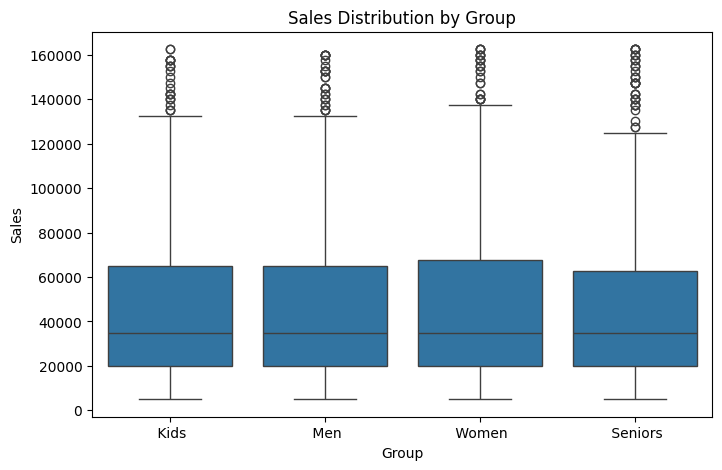

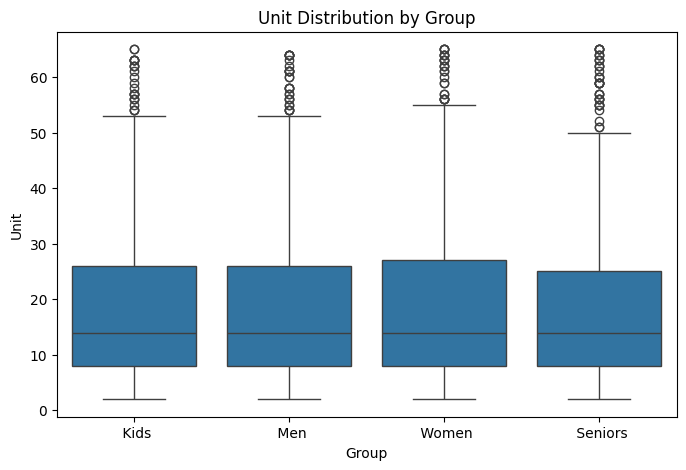

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df.reset_index(), x='Group', y='Sales')
plt.title('Sales Distribution by Group')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df.reset_index(), x='Group', y='Unit')
plt.title('Unit Distribution by Group')
plt.show()

## 4. Time-based Analysis

In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

weekly_sales = df.resample('W')['Sales'].sum()
monthly_sales = df.resample('M')['Sales'].sum()
quarterly_sales = df.resample('Q')['Sales'].sum()
daily_sales = df.resample('D')['Sales'].sum()

C:\Users\Vignesh_S16\AppData\Local\Temp\ipykernel_39260\3619203176.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M')['Sales'].sum()
C:\Users\Vignesh_S16\AppData\Local\Temp\ipykernel_39260\3619203176.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = df.resample('Q')['Sales'].sum()


## 5.1 State-wise Sales by Group

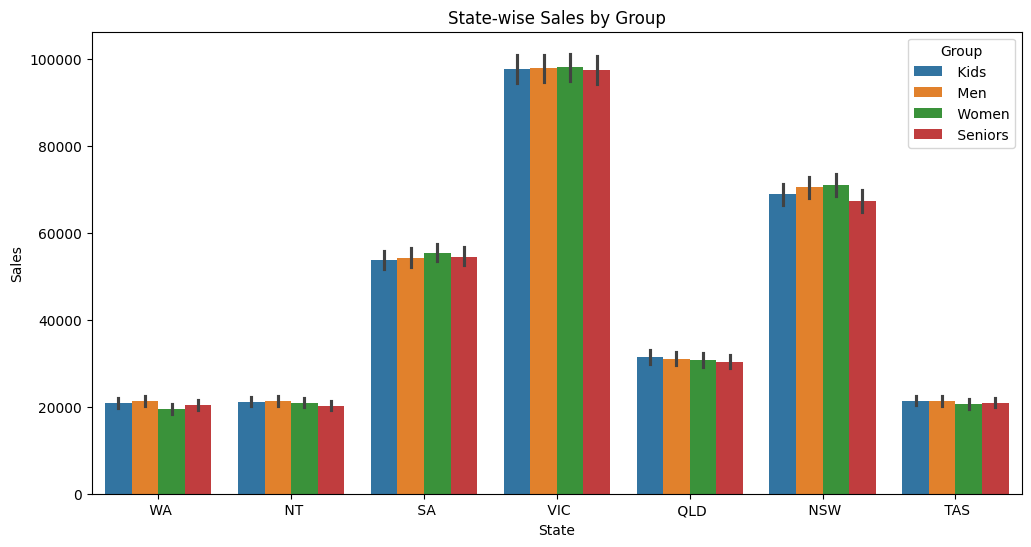

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(data=df.reset_index(), x='State', y='Sales', hue='Group')
plt.title('State-wise Sales by Group')
plt.show()

## 5.2 Stacked State-wise Sales

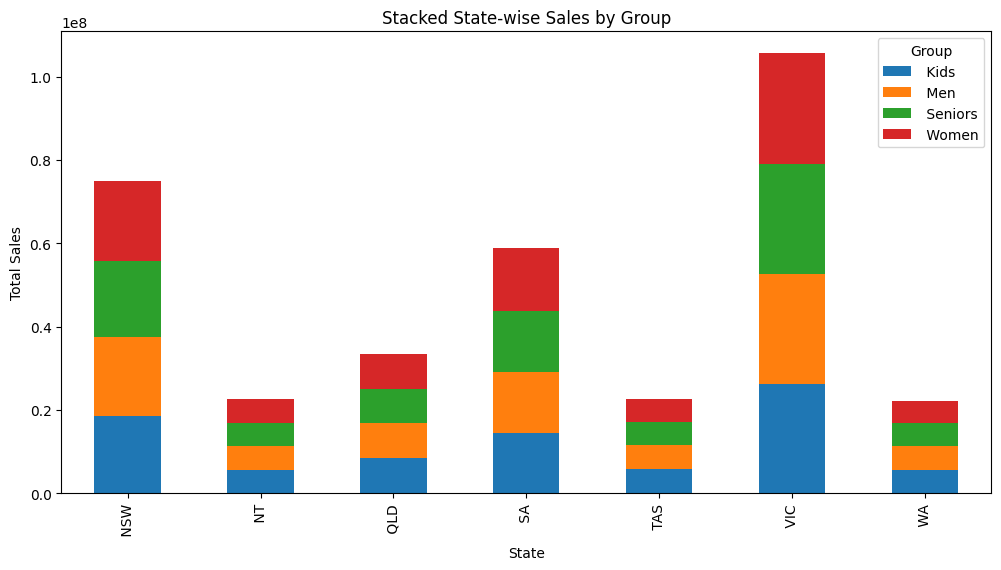

In [14]:
state_group_pivot = df.reset_index().pivot_table(index='State', columns='Group', values='Sales', aggfunc='sum')
state_group_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Stacked State-wise Sales by Group')
plt.ylabel('Total Sales')
plt.show()

## 5.3 Time-of-Day Analysis

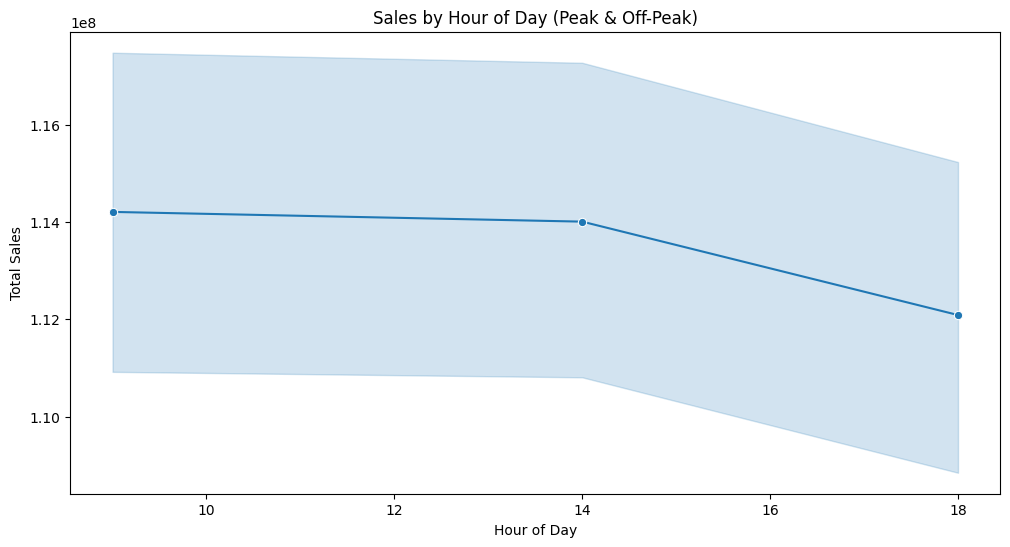

In [15]:
time_mapping = {' Morning':9, ' Afternoon':14, ' Evening':18, ' Night':21}
df['Hour'] = df['Time'].map(time_mapping)

plt.figure(figsize=(12,6))
sns.lineplot(data=df.reset_index(), x='Hour', y='Sales', estimator='sum', marker='o')
plt.title('Sales by Hour of Day (Peak & Off-Peak)')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.show()

## 5.4 Heatmap by Hour & Group

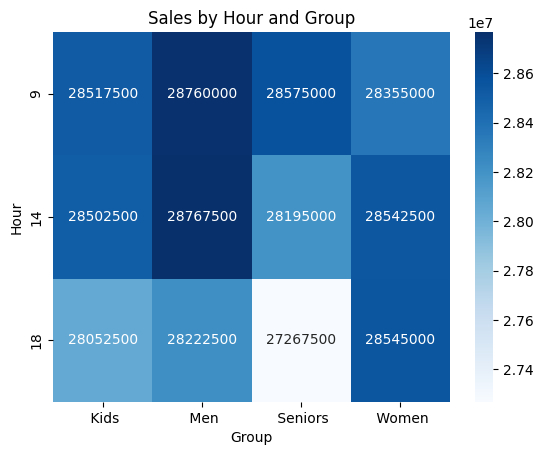

In [16]:
hour_group_pivot = df.reset_index().pivot_table(index='Hour', columns='Group', values='Sales', aggfunc='sum')
sns.heatmap(hour_group_pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Sales by Hour and Group')
plt.show()

## 5.5 Weekly, Monthly, Quarterly, Daily Charts

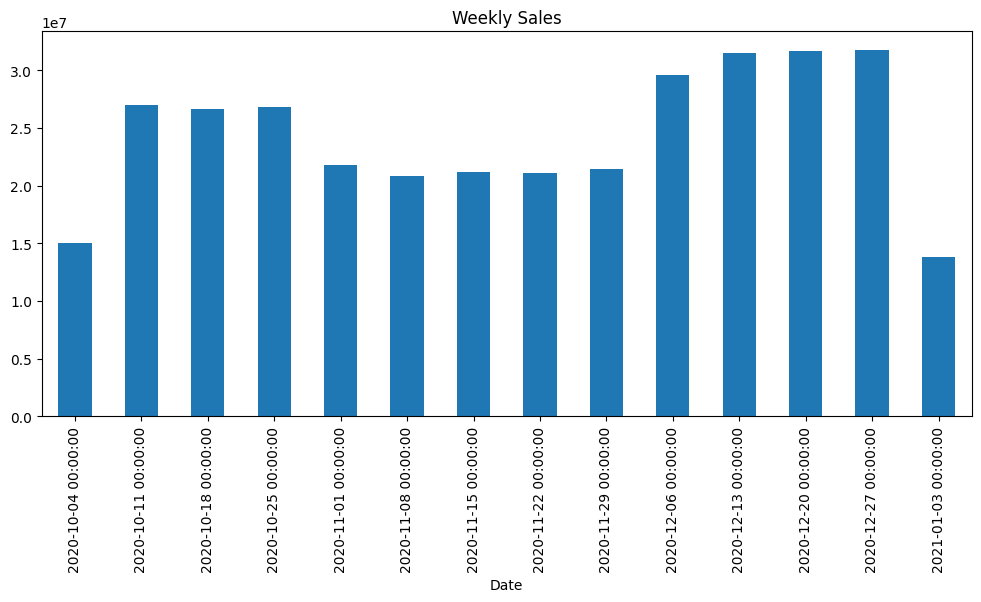

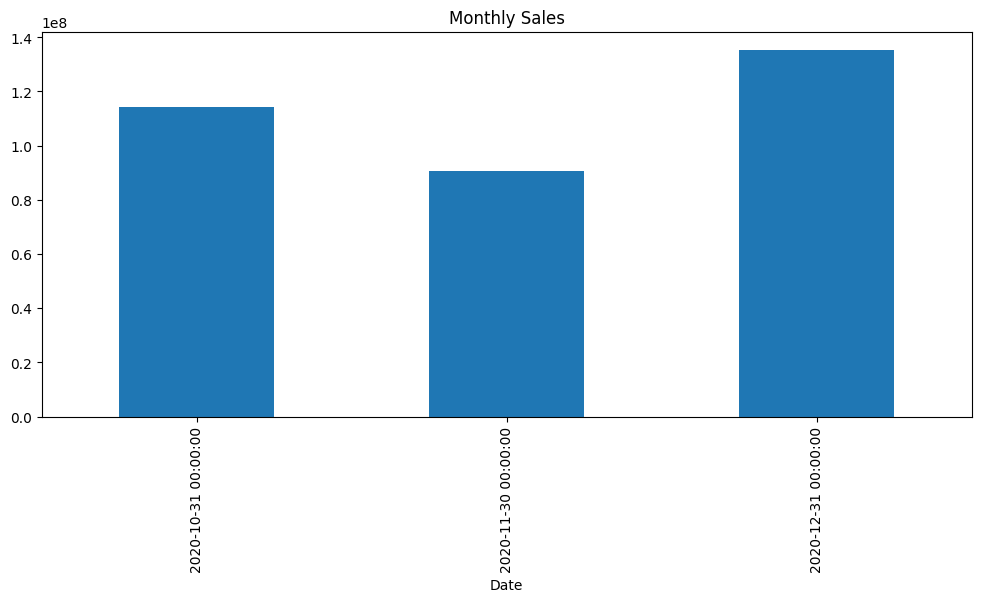

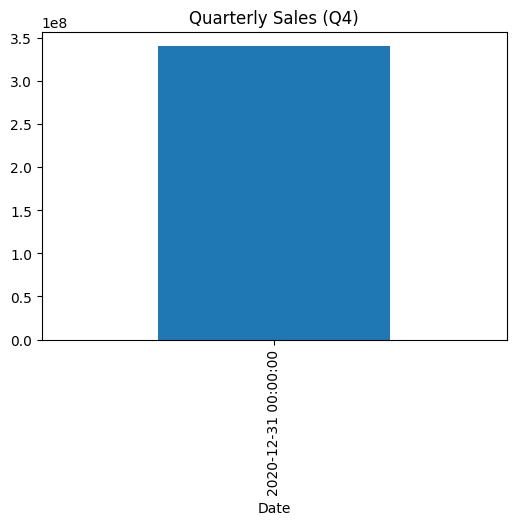

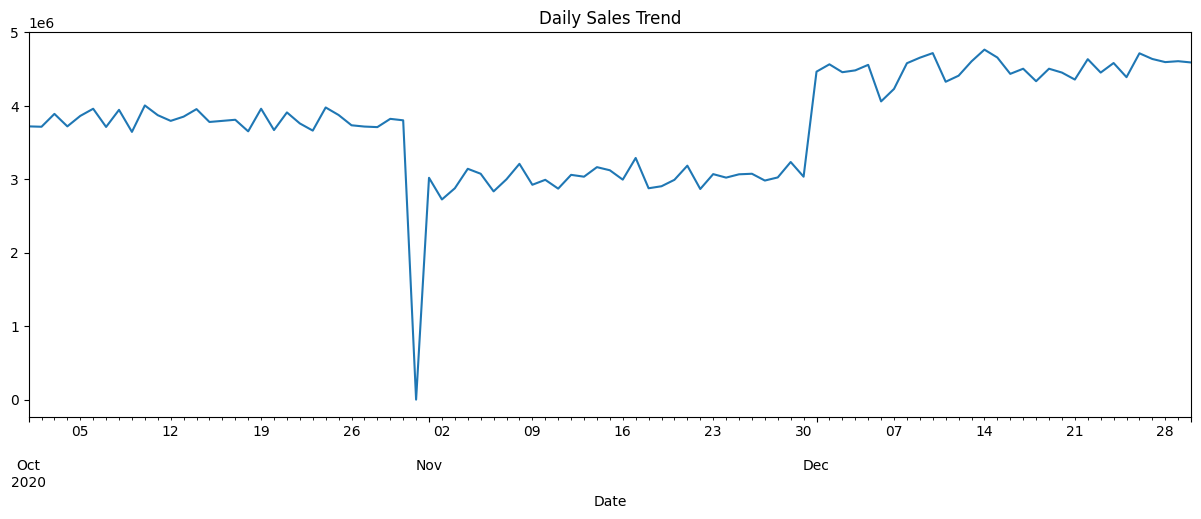

In [17]:
plt.figure(figsize=(12,5))
weekly_sales.plot(kind='bar')
plt.title('Weekly Sales')
plt.show()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales')
plt.show()

plt.figure(figsize=(6,4))
quarterly_sales.plot(kind='bar')
plt.title('Quarterly Sales (Q4)')
plt.show()

plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.show()

## 6. Recommendations
- Target low-revenue states (e.g., {lowest_state}) with campaigns, loyalty programs, and seasonal promotions.
- Focus on high-performing groups (Women & Kids) with upselling and bundle offers.
- Run flash sales during peak hours; introduce discounts during off-peak hours.
- Track weekly and monthly trends to adjust promotions dynamically.
- Box plot for descriptive statistics. Seaborn distribution plot for statistical plotting.